This notebook demonstrates a latent data assimilation method to assimilate the Kuramoto–Sivashinsky (KS) system:

$$u_{t} + u_{xx} + u_{xxxx} + \frac{1}{2}(u^2)_x = 0$$

It uses a differentiable spectral solver for the model dynamics and a VAE decoder for latent data assimilation, following:
- https://doi.org/10.1126/sciadv.aea4248
- https://doi.org/10.48550/arXiv.2405.13711

We train a VAE and use it to initialize the strong-constraint 4D-Var in the latent space, where we also define a background prior as a Normal distribution in the latent space.

In [1]:
import os
import torch
from matplotlib import pyplot as plt
import numpy as np
from time import time
import random as rd
from tensordict import TensorDict
from NLADV.advect_solver import NonlinAdv1D
from NLADV.time_stepping import ETDRK2
from VAE.vae_model import VAE
import torch
os.chdir('..')
from adda.variational.strong_constraint_4dvar import sc4dvar_single_window
from adda.variational.weak_constraint_4dvar import wc4dvar_single_window
from adda.system.state import State
from adda.util.visualization import show_1dseqimg
from adda.observation.operators import random_sparse_noisy_obs
from adda.util.initialization import naive_initialization
from adda.probability.distributions import DiagonalGaussian

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
torch.backends.cudnn.deterministic = True
torch.manual_seed(42)

cpu


## Differentiable Solver

We use the VAE layers for latent-da but we still need a differentiable solver for 4dvar.

In [2]:
# Experiment parameters
domain_size = 100.0
num_spat = 128
dt = 0.1
# These are the coeefficients for the linear terms of the KS equation.
coeffs = [0, 0, -1.0, 0, -1.0]
# Exponential Time Differencing Runge-Kutta 2nd order (ETDRK2).
integrator = ETDRK2
# Create the solver object, which will be used as the forward operator in the 4D-Var optimization.
forward_operator = NonlinAdv1D(domain_size=domain_size, num_spat=num_spat, dt=dt, linear_coeffs=coeffs, advect_coeff=1.0, integrator=integrator)

## Loading the data from Disk

We load a single trajectory for data assimilation. This trajectory comes from the testing set of the VAE. We could generate a new trajectory with the differentiable simulator too. However, it is easier to ascertain that the sample is not included in the training set of the VAE.

In [3]:
import h5py

# Open the HDF5 file
with h5py.File("notebooks/VAE/data.h5", "r") as f:
    data = f["data"][0]
    data_mean = f["mean"][()]
    data_std = f["std"][()]
# We will need the mean and std of the training data for normalization/denormalization
# in the projection operator.
data_tensor = torch.from_numpy(data).float().to(device)
print(data_tensor.shape)  # should be (800, 128)
num_timesteps, length = data_tensor.shape

torch.Size([800, 128])


Text(0, 0.5, 'space')

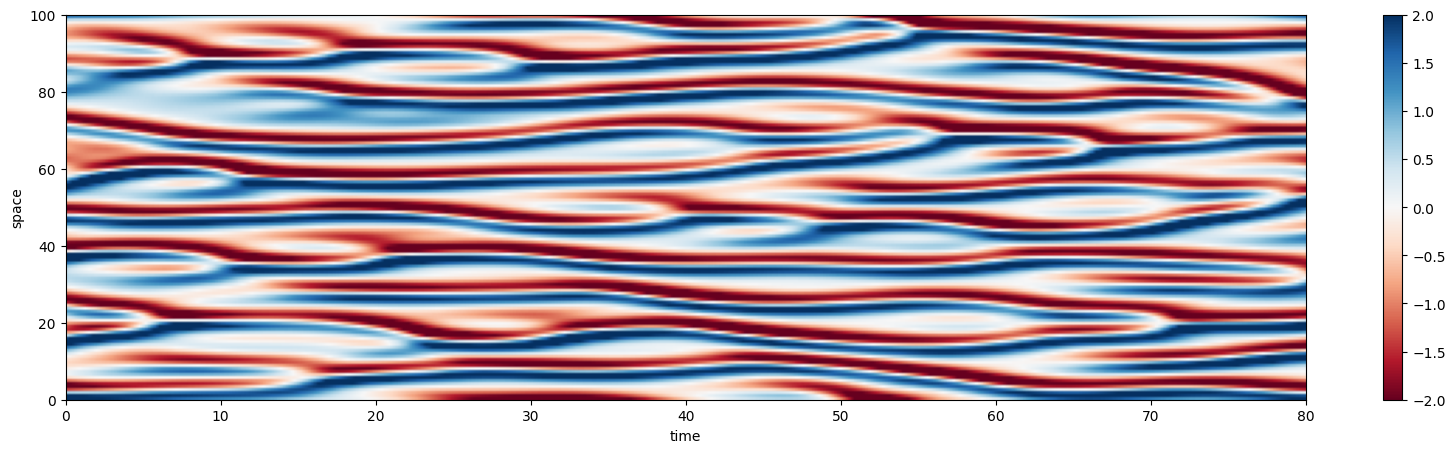

In [4]:
# The burn-in cutoff is already applied before training the VAE.
plt.figure(figsize=(20, 5))
plt.imshow(
    data.transpose(),
    cmap="RdBu",
    aspect="auto",
    origin="lower",
    extent=(0, data.shape[0] * dt, 0, domain_size),
    vmin=-2,
    vmax=2,
)
plt.colorbar()
plt.xlabel("time")
plt.ylabel("space")

## Loading the VAE model to use as a projection operator in the 4D-Var optimization.

In [5]:
trained_model_path = "notebooks/VAE/vae_best.pth"
vae_model = VAE(trained_model_path).to(device)
latent_dim = 32

Loaded checkpoint from notebooks/VAE/vae_best.pth


In [6]:
true_series = data_tensor
true_initial_state = true_series[0]
forecast_steps = torch.arange(0, data_tensor.shape[0] * dt, dt)
true_series = State(true_series.reshape(1, -1, num_spat), time_axis=forecast_steps)

Text(0.5, 1.0, 'Initial Ground Truth State of the KS System')

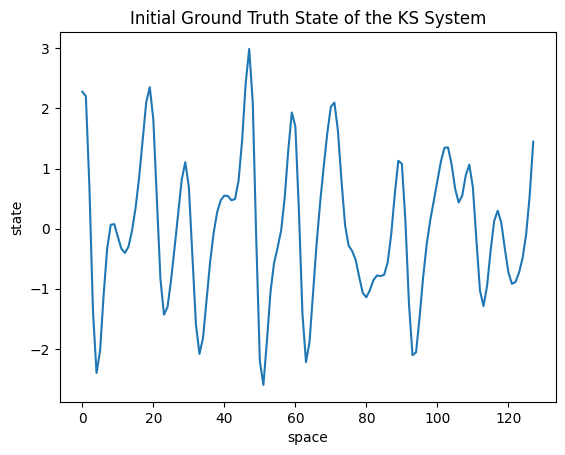

In [7]:
plt.plot(true_initial_state)
plt.xlabel("space")
plt.ylabel("state")
plt.title("Initial Ground Truth State of the KS System")

In [8]:
# In order to use the 4D-Var function, you should always have a function like this taking the state, dt, dynamic_inputs and static_inputs
def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    B, T = x.fields.batch_size[:2]
    input = x.fields["x"].reshape(B * T, num_spat)
    integrated = forward_operator.integrate(torch.arange(2) * dt, input)[:, -2:-1] # integrate over a time step, take the current time
    integrated = integrated.reshape(B, T, num_spat)
    new_fields = TensorDict(x=integrated, batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + dt)  # return State object, advancing time

In [9]:
decoder = vae_model.decoder
encoder = vae_model.encoder
def projection_operator(x: TensorDict):
    B, T = x.batch_size[:2]
    input = x["x"].reshape(B * T, latent_dim)
    decoded = decoder(input)
    # since the decoder outputs normalized data, we need to denormalize it to get the actual state variables.
    decoded = decoded.reshape(B, T, num_spat) * data_std + data_mean 
    return TensorDict(x=decoded, batch_size=(B, T))

# We use the encoder part of the VAE to get a posterior distribution in the latent space, 
# which will be used as the initial guess for the 4D-Var optimization.
def encode_to_get_posterior_from_naive_init(x_init: State):
    B, T = x_init.fields.batch_size[:2]
    input = x_init.fields["x"].reshape(B * T, 1, num_spat)
    input = (input - data_mean) / data_std
    with torch.no_grad():
        mu, log_var = encoder(input) # take mean and log variance of latent distribution
    z = mu.reshape(B, T, latent_dim) # reshape to (B, T, latent_dim)
    new_fields = TensorDict(x=z, batch_size=(B, T))
    return State(new_fields, time_axis=x_init.time_axis)

### Check a generated sample from the prior with the decoder of the VAE.

Text(0.5, 1.0, 'A random sample from the VAE prior in the physical space')

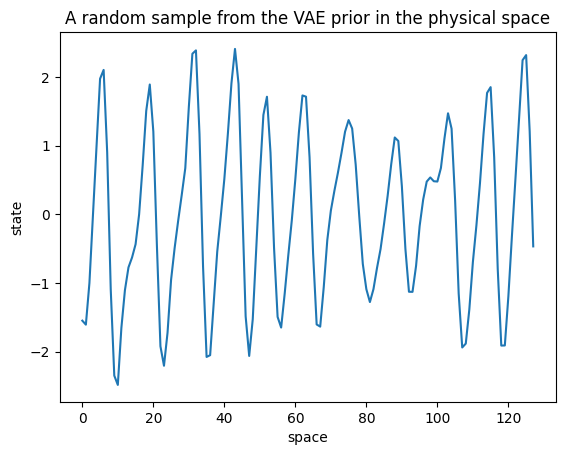

In [10]:
z_random = torch.randn(1, vae_model.encoder.latent_dim, device=device).unsqueeze(1) # add time dimension
z_state = TensorDict(x=z_random, batch_size=(1, 1))
x_state = projection_operator(z_state)
plt.plot(x_state['x'][0, 0].detach().cpu().numpy())
plt.xlabel("space")
plt.ylabel("state")
plt.title("A random sample from the VAE prior in the physical space")

# Strong-constraint 4D-var

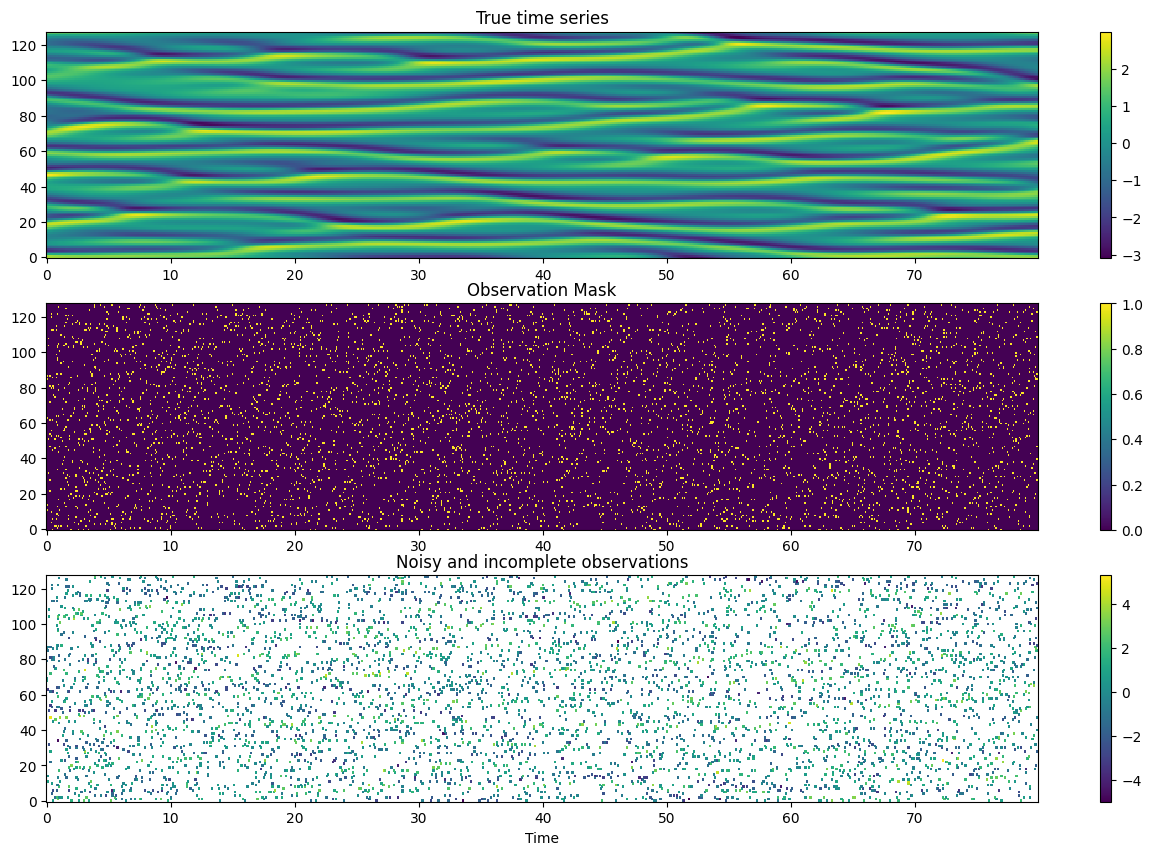

In [11]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.05 # 95% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_series, noise_amplitude, p_obs)

valid_obs = observations.state.fields['x'][0].T
valid_obs[torch.logical_not(observations.mask.fields['x'][0].T)] = torch.nan
fig, ax = plt.subplots(3, 1, figsize=(16,10))

show_1dseqimg(true_series.fields['x'][0].T, dt=dt, ax=ax[0], title="True time series")
show_1dseqimg(observations.mask.fields['x'][0].T, dt=dt, ax=ax[1], title="Observation Mask")
show_1dseqimg(valid_obs, dt=dt, ax=ax[2], title="Noisy and incomplete observations", x_label="Time")

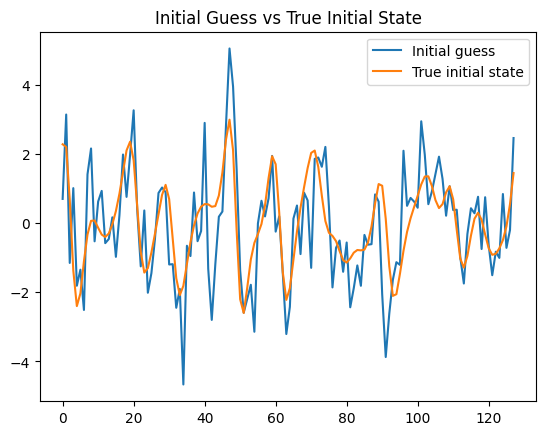

In [12]:
initialization = naive_initialization(observations)  # state estimate for all time points
initialization = initialization[:, :1]  # first time point only

plt.plot(initialization.fields['x'].squeeze(), label='Initial guess')
plt.plot(true_series.fields['x'].squeeze()[0], label='True initial state')
plt.legend()
plt.title("Initial Guess vs True Initial State")
plt.show()

torch.Size([1, 1, 32])


Text(0.5, 1.0, 'Encoded Initialization in the Latent Space')

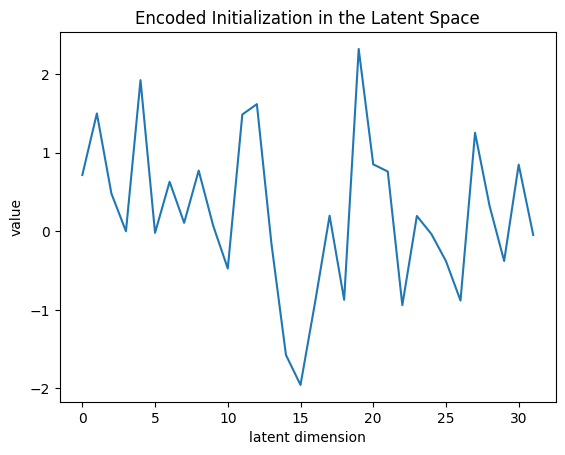

In [13]:
# We can check the encoded initialization in the latent space.
z_init = encode_to_get_posterior_from_naive_init(initialization)
print(z_init.fields['x'].shape) # Should be (1, 1, latent_dim)
plt.plot(z_init.fields['x'].squeeze().cpu().numpy())
plt.xlabel("latent dimension")
plt.ylabel("value")
plt.title("Encoded Initialization in the Latent Space")

In [14]:
n_obs_steps = 100 #Time steps to assimilate.
time_window = (observations.state.time_axis[0], observations.state.time_axis[n_obs_steps])

obs_op_opt = obs_op.restrict_time_domain(*time_window)
observations_opt = observations.restrict_time_domain(*time_window)

print(obs_op.mask.fields)

TensorDict(
    fields={
        x: Tensor(shape=torch.Size([1, 800, 128]), device=cpu, dtype=torch.bool, is_shared=False)},
    batch_size=torch.Size([1, 800]),
    device=None,
    is_shared=False)


In [15]:
# Since we trained the VAE with a standard normal prior in the latent space, we can use that as the background prior for the 4D-Var optimization.
background_prior = DiagonalGaussian(torch.zeros(1, 1, latent_dim), 
                                        torch.ones(1, 1, latent_dim))

In [16]:
# This should run in about a minute
t0 = time()
assimilated_ic = sc4dvar_single_window(m_dyn=next_step_function, 
                                       observations=observations_opt, 
                                       obs_op=obs_op_opt, 
                                       x_init=z_init,
                                       background_prior=background_prior,  
                                       optimizer_pars={'lr': 1e-1},
                                       n_steps=20,
                                       c_proj=projection_operator)                                 
print(f'Total time for the 4Dvar optimization: {time() - t0} seconds')

Total time for the 4Dvar optimization: 118.90399241447449 seconds


In [17]:
# We want to see the effect of the background prior, so we run the optimization without it as well.
assimilated_ic_wo_bp = sc4dvar_single_window(m_dyn=next_step_function,
                                       observations=observations_opt, 
                                       obs_op=obs_op_opt, 
                                       x_init=z_init,                                     
                                       optimizer_pars={'lr': 1e-1},
                                       n_steps=20,
                                       c_proj=projection_operator)                                 
print(f'Total time for the 4Dvar optimization without background prior: {time() - t0} seconds')

Total time for the 4Dvar optimization without background prior: 247.30898189544678 seconds


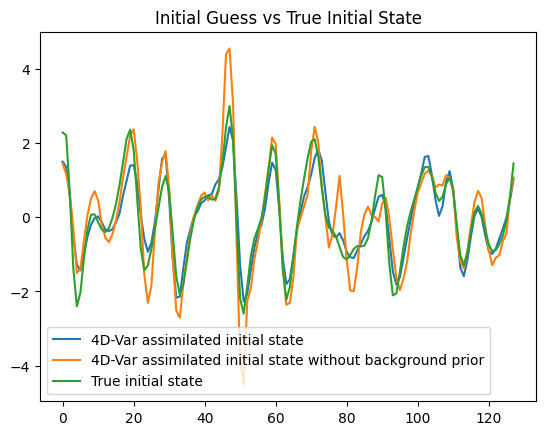

In [18]:
x_state = projection_operator(assimilated_ic.fields)
x_state_wo_bp = projection_operator(assimilated_ic_wo_bp.fields)
plt.plot(x_state['x'][0, 0].detach().cpu().numpy(), label='4D-Var assimilated initial state')
plt.plot(x_state_wo_bp['x'][0, 0].detach().cpu().numpy(), label='4D-Var assimilated initial state without background prior')
plt.plot(true_series.fields['x'].squeeze()[0], label='True initial state')
plt.legend()
plt.title("Initial Guess vs True Initial State")
plt.show()

In [19]:
# We compare the trajectories obtained by integrating forward the assimilated initial conditions, the initial guess, and encode-decode of the initial guess.
z_init = encode_to_get_posterior_from_naive_init(initialization)
x_encode_decode = projection_operator(z_init.fields)

assim_input = x_state['x'].reshape(1, num_spat)
assim_input_wo_bp = x_state_wo_bp['x'].reshape(1, num_spat)
initialization_input = initialization.fields['x'].reshape(1, num_spat)
encode_decode_input = x_encode_decode['x'].reshape(1, num_spat)
assimilated_trajectory = forward_operator.integrate(time=forecast_steps, state=assim_input).squeeze()
assimilated_trajectory_wo_bp = forward_operator.integrate(time=forecast_steps, state=assim_input_wo_bp).squeeze()
trajectories_from_initial_guess = forward_operator.integrate(time=forecast_steps, state=initialization_input).squeeze()
trajectory_from_encode_decode = forward_operator.integrate(time=forecast_steps, state=encode_decode_input).squeeze()

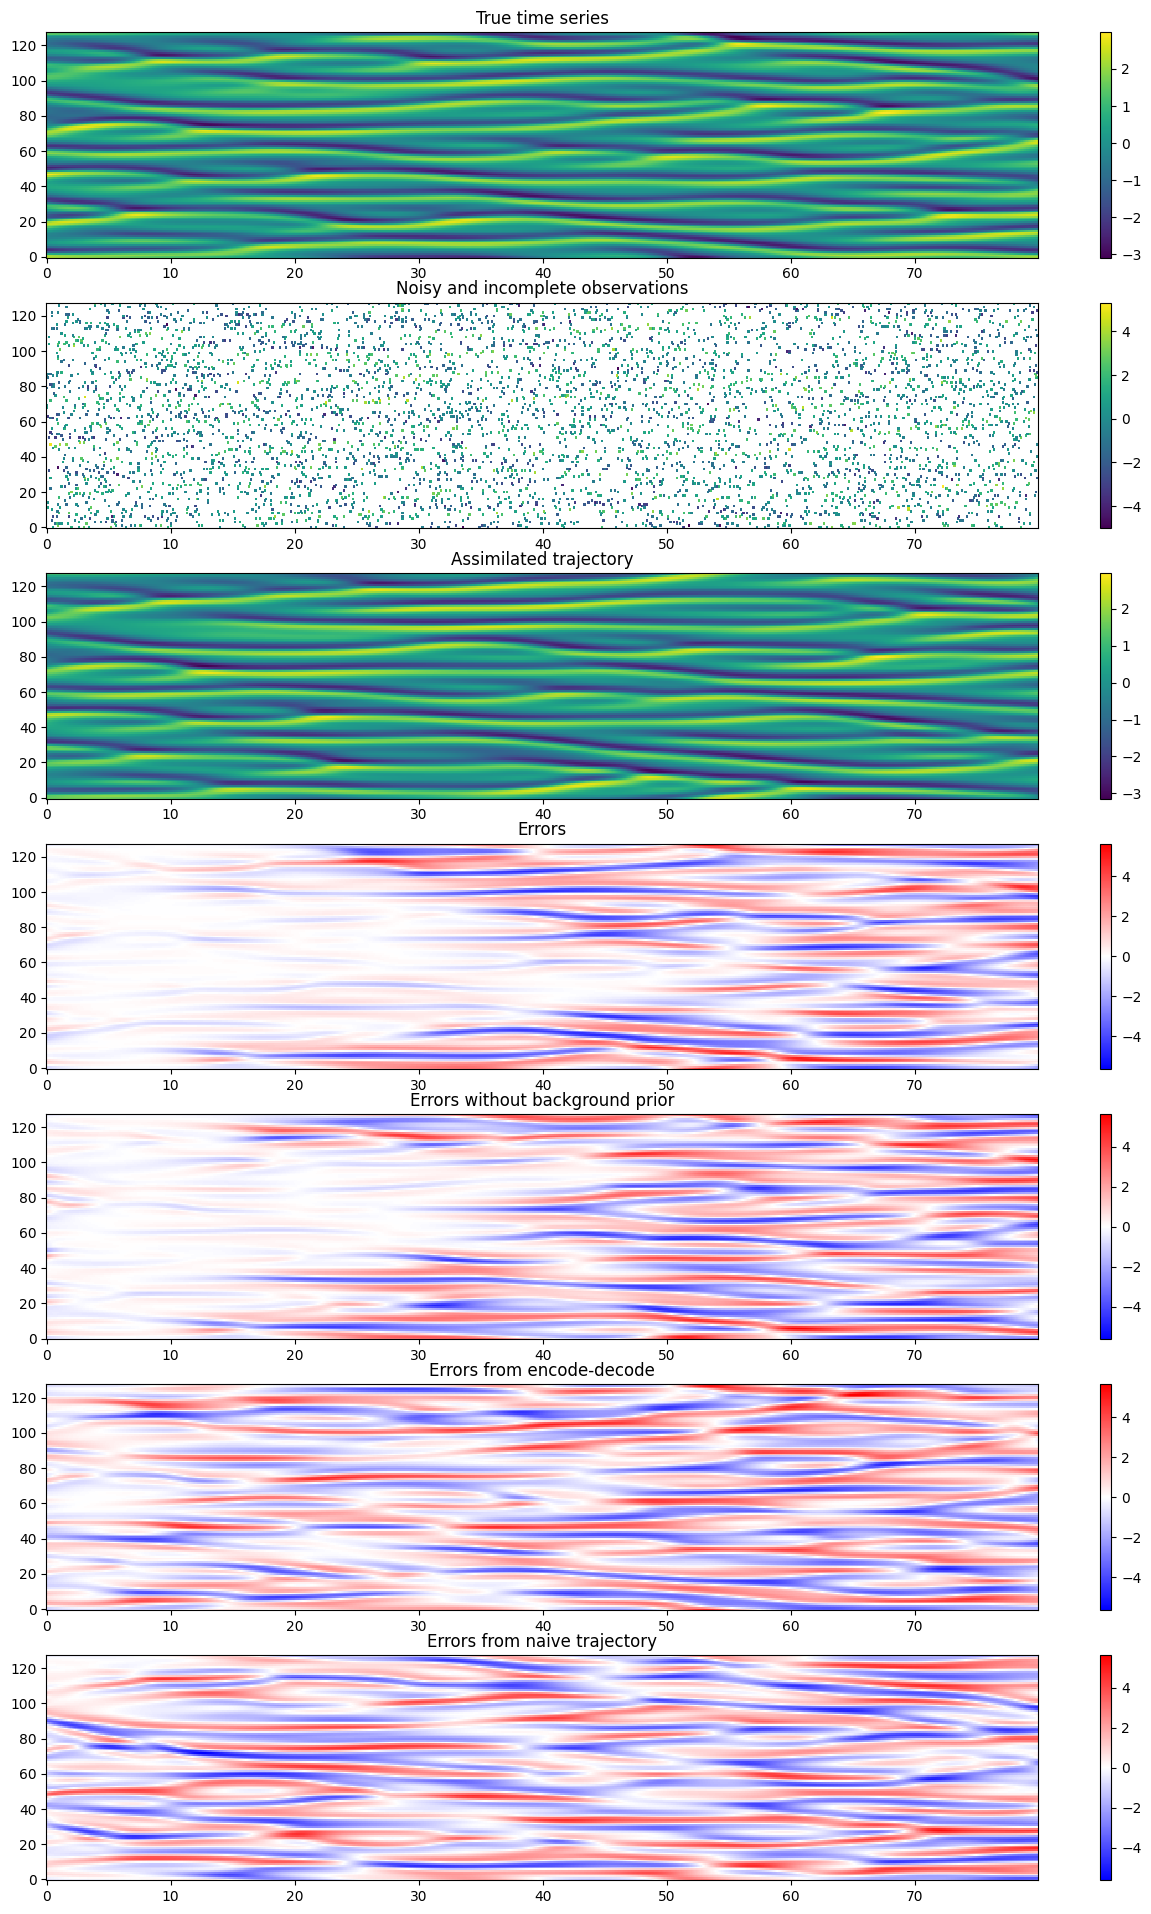

In [20]:
error = assimilated_trajectory.detach() - true_series.fields['x']
error_wo_bp = assimilated_trajectory_wo_bp.detach() - true_series.fields['x']
error_encode_decode = trajectory_from_encode_decode.detach() - true_series.fields['x']
error_naive = trajectories_from_initial_guess.detach() - true_series.fields['x']
fig, ax = plt.subplots(7, 1, figsize=(16,24))
show_1dseqimg(true_series.fields['x'][0].T, dt=dt, ax=ax[0], title="True time series")
show_1dseqimg(valid_obs, dt=dt, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg(assimilated_trajectory.detach().T, dt=dt, ax=ax[2], title="Assimilated trajectory")
show_1dseqimg(error.detach().squeeze().T, dt=dt, ax=ax[3], title="Errors", cmap="bwr", vmin=-torch.max(torch.abs(error_naive)), vmax=torch.max(torch.abs(error_naive)))
show_1dseqimg(error_wo_bp.detach().squeeze().T, dt=dt, ax=ax[4], title="Errors without background prior", cmap="bwr", vmin=-torch.max(torch.abs(error_naive)),  vmax=torch.max(torch.abs(error_naive)))
show_1dseqimg(error_encode_decode.detach().squeeze().T, dt=dt, ax=ax[5], title="Errors from encode-decode", cmap="bwr", vmin=-torch.max(torch.abs(error_naive)),  vmax=torch.max(torch.abs(error_naive)))
show_1dseqimg(error_naive.detach().squeeze().T, dt=dt, ax=ax[6], title="Errors from naive trajectory", cmap="bwr", vmin=-torch.max(torch.abs(error_naive)),  vmax=torch.max(torch.abs(error_naive)))

torch.Size([800])
torch.Size([800])


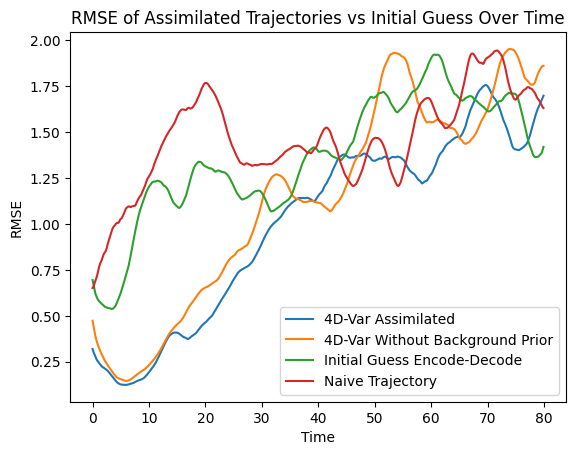

In [21]:
RMSE_over_time_assimilated = torch.mean(torch.sqrt((error.squeeze().T ** 2)), dim=0)
RMSE_over_time_wo_bp = torch.mean(torch.sqrt((error_wo_bp.squeeze().T ** 2)), dim=0)
RMSE_over_time_initial = torch.mean(torch.sqrt((error_encode_decode.squeeze().T ** 2)), dim=0)
RMSE_over_time_naive = torch.mean(torch.sqrt((error_naive.squeeze().T ** 2)), dim=0)
print(RMSE_over_time_initial.shape)
print(RMSE_over_time_assimilated.shape)

fig, ax = plt.subplots()
plt.plot(forecast_steps, RMSE_over_time_assimilated.squeeze(), label='4D-Var Assimilated')
plt.plot(forecast_steps, RMSE_over_time_wo_bp.squeeze(), label='4D-Var Without Background Prior')
plt.plot(forecast_steps, RMSE_over_time_initial.squeeze(), label='Initial Guess Encode-Decode')
plt.plot(forecast_steps, RMSE_over_time_naive.squeeze(), label='Naive Trajectory')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE')
plt.title("RMSE of Assimilated Trajectories vs Initial Guess Over Time")
plt.legend()
plt.show()

torch.Size([800])
torch.Size([800])


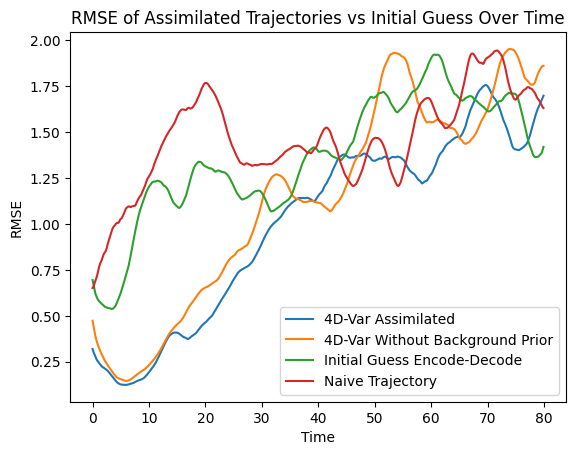

In [22]:
RMSE_over_time_assimilated = torch.mean(torch.sqrt((error.squeeze().T ** 2)), dim=0)
RMSE_over_time_wo_bp = torch.mean(torch.sqrt((error_wo_bp.squeeze().T ** 2)), dim=0)
RMSE_over_time_initial = torch.mean(torch.sqrt((error_encode_decode.squeeze().T ** 2)), dim=0)
RMSE_over_time_naive = torch.mean(torch.sqrt((error_naive.squeeze().T ** 2)), dim=0)
print(RMSE_over_time_initial.shape)
print(RMSE_over_time_assimilated.shape)

fig, ax = plt.subplots()
plt.plot(forecast_steps, RMSE_over_time_assimilated.squeeze(), label='4D-Var Assimilated')
plt.plot(forecast_steps, RMSE_over_time_wo_bp.squeeze(), label='4D-Var Without Background Prior')
plt.plot(forecast_steps, RMSE_over_time_initial.squeeze(), label='Initial Guess Encode-Decode')
plt.plot(forecast_steps, RMSE_over_time_naive.squeeze(), label='Naive Trajectory')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE')
plt.title("RMSE of Assimilated Trajectories vs Initial Guess Over Time")
plt.legend()
plt.show()

We see a slight improvement with the prior at the beginning of the rollout but it diminishes over time.

Another notable improvement enabled by the background prior is that the running time of the assimilation is lower.